In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from scipy.ndimage import uniform_filter1d

In [3]:
def smooth(values, window=3):
    if len(values) < window:
        return values
    return uniform_filter1d(values, size=window)

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/task2/seg_train/seg_train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
     shuffle=True
)

Found 11230 images belonging to 6 classes.


In [6]:
val_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/task2/seg_train/seg_train",
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2804 images belonging to 6 classes.


In [7]:
test_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/task2/seg_test/seg_test",
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


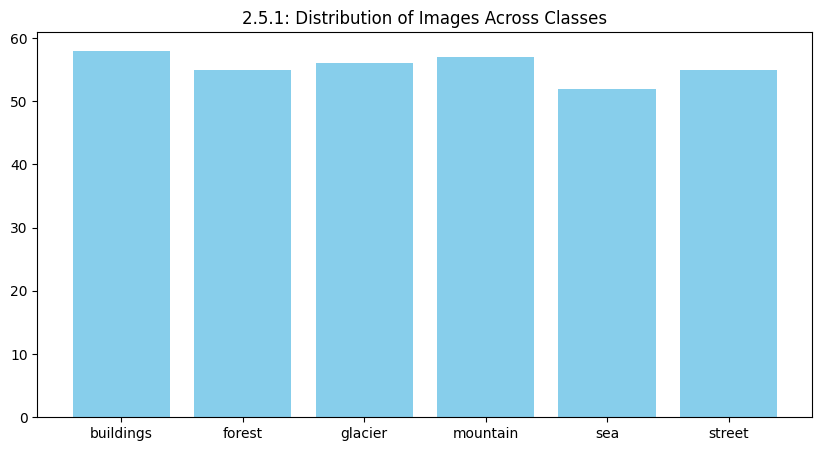

In [10]:
train_dir = '/content/drive/MyDrive/task2/seg_train/seg_train'
classes = sorted(os.listdir(train_dir))
counts = [len(os.path.join(train_dir, c)) for c in classes]

plt.figure(figsize=(10, 5))
plt.bar(classes, counts, color='skyblue')
plt.title('2.5.1: Distribution of Images Across Classes')
plt.show()

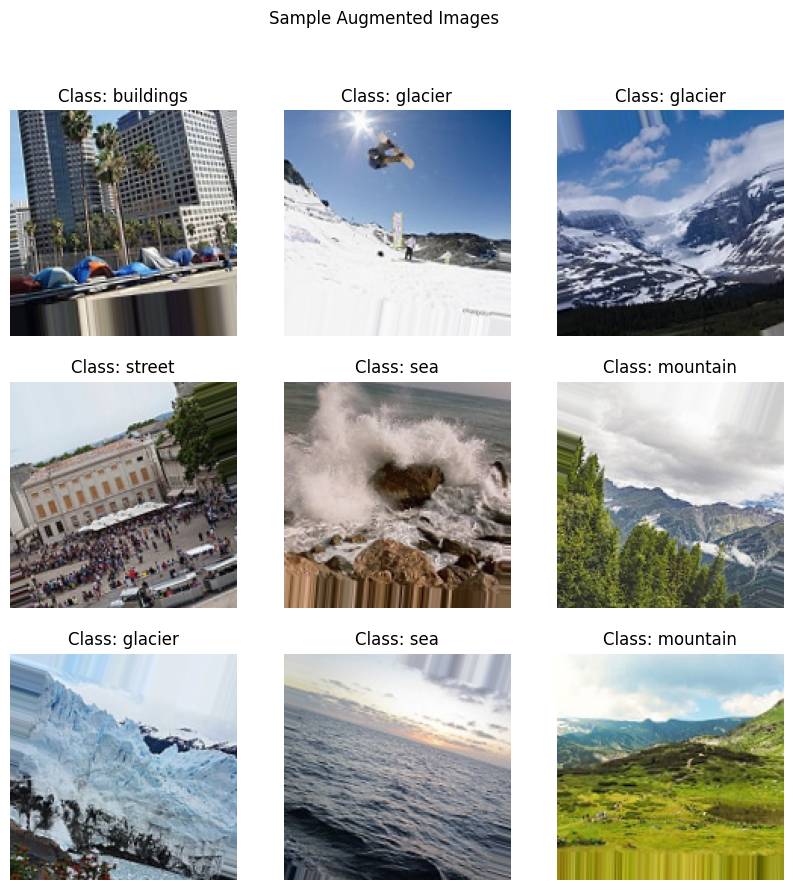

In [46]:
def visualize_augmentations(generator):
    batch = next(generator)
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(batch[0][i])
        plt.title(f"Class: {classes[np.argmax(batch[1][i])]}")
        plt.axis('off')
    plt.suptitle("Sample Augmented Images")
    plt.show()

visualize_augmentations(train_generator)

In [47]:
print(f"Dataset represents 6 categories of natural scenes: {classes}")
print(f"Total training images: {train_generator.n}")
print(f"Total validation images: {val_data.n}")
print("Preprocessing: Rescaling (1/255), Rotation, Shifts, and Horizontal Flips applied.")

Dataset represents 6 categories of natural scenes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total training images: 11230
Total validation images: 2804
Preprocessing: Rescaling (1/255), Rotation, Shifts, and Horizontal Flips applied.


In [13]:
baseline_model = Sequential([
    Input(shape=(150, 150, 3)),

    # Convolutional and Pooling layers
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    # Fully Connected Layers
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(classes), activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_data,
    epochs=20
)
baseline_duration = time.time() - start_time

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 3807s 11s/step - accuracy: 0.5644 - loss: 1.1005 - val_accuracy: 0.6430 - val_loss: 0.9418
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 126s 359ms/step - accuracy: 0.6929 - loss: 0.8159 - val_accuracy: 0.6908 - val_loss: 0.7848
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 123s 351ms/step - accuracy: 0.7347 - loss: 0.7137 - val_accuracy: 0.7636 - val_loss: 0.6704
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 125s 356ms/step - accuracy: 0.7677 - loss: 0.6356 - val_accuracy: 0.7757 - val_loss: 0.6170
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 363ms/step - accuracy: 0.7877 - loss: 0.5861 - val_accuracy: 0.8010 - val_loss: 0.5534
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 125s 355ms/step - accuracy: 0.7987 - loss: 0.5544 - val_accuracy: 0.7685 - val_loss: 0.6085
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 125s 355ms/step - accuracy: 0.8066 - loss: 0.5262 - val_accuracy: 0.8067 - val_loss: 0.5360
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 353ms/step - accuracy: 0.8225 - 

In [57]:
print(f"Baseline Training Time: {baseline_duration:.2f}s")

Baseline Training Time: 6169.26s


In [14]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,814,996 (109.92 MB)

 Trainable params: 9,604,998 (36.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,209,998 (73.28 MB)

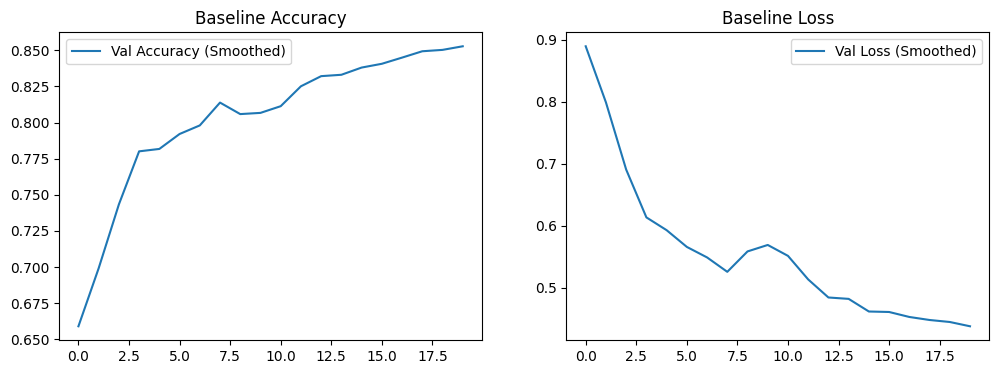

In [15]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(smooth(history_baseline.history['val_accuracy']), label='Val Accuracy (Smoothed)')
plt.title('Baseline Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(smooth(history_baseline.history['val_loss']), label='Val Loss (Smoothed)')
plt.title('Baseline Loss')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import classification_report

# Get predictions for the entire test set
test_data.reset()
y_true = test_data.classes
predictions = baseline_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
class_labels = list(test_data.class_indices.keys())

print("--- Baseline Model Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step
--- Baseline Model Classification Report ---
              precision    recall  f1-score   support

   buildings       0.87      0.81      0.84       437
      forest       0.94      0.98      0.96       474
     glacier       0.82      0.82      0.82       553
    mountain       0.86      0.74      0.80       525
         sea       0.84      0.89      0.86       510
      street       0.84      0.92      0.88       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step


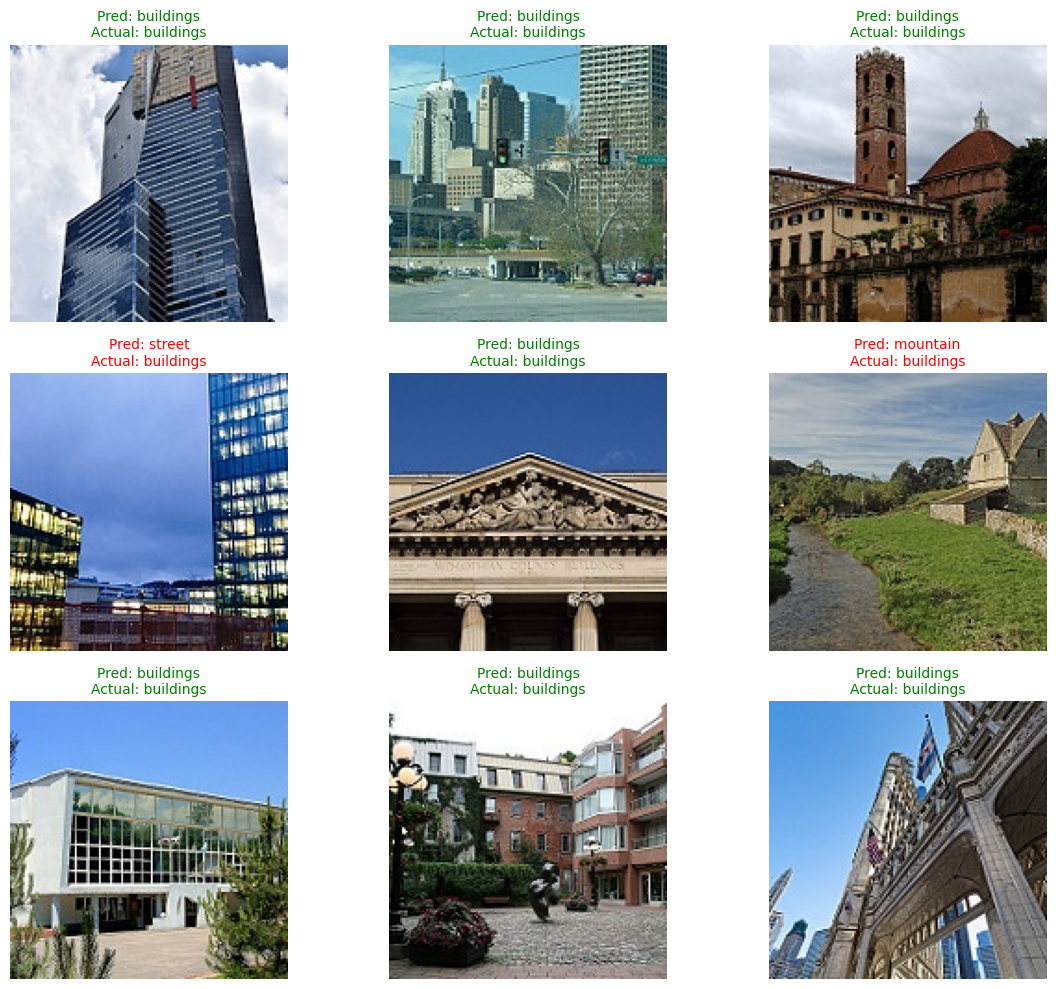

In [19]:
plt.figure(figsize=(12, 10))

# Get a batch of images and their true labels from the test data
images_batch, labels_batch = next(test_data)

# Get predictions for this specific batch
predictions_batch = baseline_model.predict(images_batch)

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i])

    pred_idx = np.argmax(predictions_batch[i])
    true_idx = np.argmax(labels_batch[i])

    pred_name = class_labels[pred_idx]
    true_name = class_labels[true_idx]

    color = 'green' if pred_name == true_name else 'red'

    plt.title(f"Pred: {pred_name}\nActual: {true_name}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Deeper Architecture

In [22]:
deeper_model = Sequential([
    Input(shape=(150, 150, 3)),

    #  Double Conv Layers
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    # Increased filters
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    # Even deeper
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Flatten(),

    # Fully Connected Layers with Dropout
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(classes), activation='softmax')
])

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the deeper model

print("Training Deeper Model ...")
start_time_deeper = time.time()
history_deeper = deeper_model.fit(
    train_generator,
    validation_data=val_data,
    epochs=25
)
deeper_duration = time.time() - start_time_deeper
print(f"Deeper Model Training Completed in: {deeper_duration:.2f} seconds")

Training Deeper Model ...
Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 166s 427ms/step - accuracy: 0.4139 - loss: 2.1364 - val_accuracy: 0.2561 - val_loss: 1.9545
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 134s 381ms/step - accuracy: 0.5529 - loss: 1.1405 - val_accuracy: 0.6063 - val_loss: 1.0129
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 133s 379ms/step - accuracy: 0.6083 - loss: 1.0122 - val_accuracy: 0.6526 - val_loss: 0.9312
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 134s 381ms/step - accuracy: 0.6481 - loss: 0.9263 - val_accuracy: 0.5371 - val_loss: 1.2812
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 134s 381ms/step - accuracy: 0.7063 - loss: 0.8128 - val_accuracy: 0.6205 - val_loss: 1.2115
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 131s 372ms/step - accuracy: 0.7362 - loss: 0.7429 - val_accuracy: 0.5749 - val_loss: 1.1927
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 133s 380ms/step - accuracy: 0.7485 - loss: 0.7046 - val_accuracy: 0.7111 - val_loss: 0.7545
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 131s 374ms

In [23]:
deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,815,092 (125.18 MB)

 Trainable params: 10,938,214 (41.73 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 21,876,430 (83.45 MB)

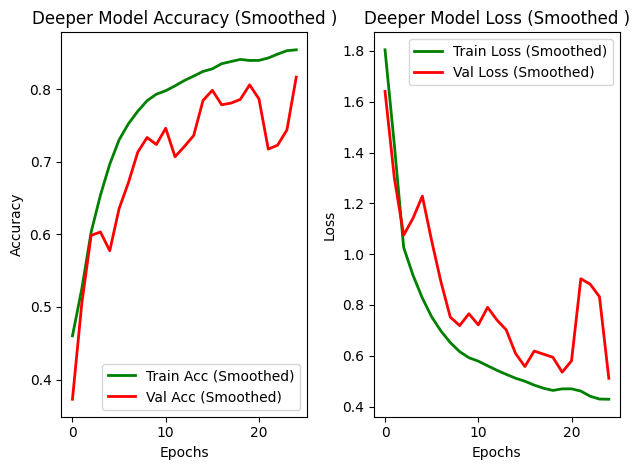

In [69]:
plt.subplot(1, 2, 1)
plt.plot(smooth(history_deeper.history['accuracy']), label='Train Acc (Smoothed)', color='green', linewidth=2)
plt.plot(smooth(history_deeper.history['val_accuracy']), label='Val Acc (Smoothed)', color='red', linewidth=2)
plt.title('Deeper Model Accuracy (Smoothed )')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss (Smoothed)
plt.subplot(1, 2, 2)
plt.plot(smooth(history_deeper.history['loss']), label='Train Loss (Smoothed)', color='green', linewidth=2)
plt.plot(smooth(history_deeper.history['val_loss']), label='Val Loss (Smoothed)', color='red', linewidth=2)
plt.title('Deeper Model Loss (Smoothed )')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Comparision:Baseline vs Deeper Model**

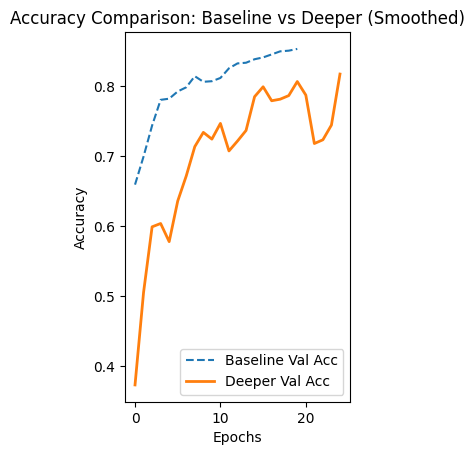

In [25]:
plt.subplot(1, 2, 2)
plt.plot(smooth(history_baseline.history['val_accuracy']), label='Baseline Val Acc', linestyle='--')
plt.plot(smooth(history_deeper.history['val_accuracy']), label='Deeper Val Acc', linewidth=2)
plt.title('Accuracy Comparison: Baseline vs Deeper (Smoothed)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

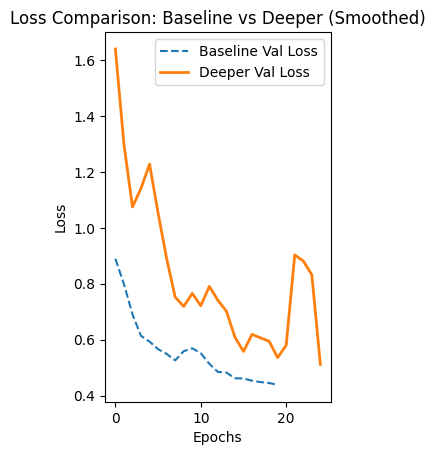

In [26]:
plt.subplot(1, 2, 1)
plt.plot(smooth(history_baseline.history['val_loss']), label='Baseline Val Loss', linestyle='--')
plt.plot(smooth(history_deeper.history['val_loss']), label='Deeper Val Loss', linewidth=2)
plt.title('Loss Comparison: Baseline vs Deeper (Smoothed)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [27]:
print(f"Baseline Time: {baseline_duration:.2f}s | Deeper Time: {deeper_duration:.2f}s")

Baseline Time: 6169.26s | Deeper Time: 3342.74s


**Model Evaluation:**

In [29]:
test_data.reset()
predictions = deeper_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

class_names = list(test_data.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step
              precision    recall  f1-score   support

   buildings       0.58      0.95      0.72       437
      forest       0.97      0.92      0.95       474
     glacier       0.82      0.80      0.81       553
    mountain       0.89      0.54      0.68       525
         sea       0.74      0.93      0.82       510
      street       0.87      0.58      0.70       501

    accuracy                           0.78      3000
   macro avg       0.81      0.79      0.78      3000
weighted avg       0.82      0.78      0.78      3000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


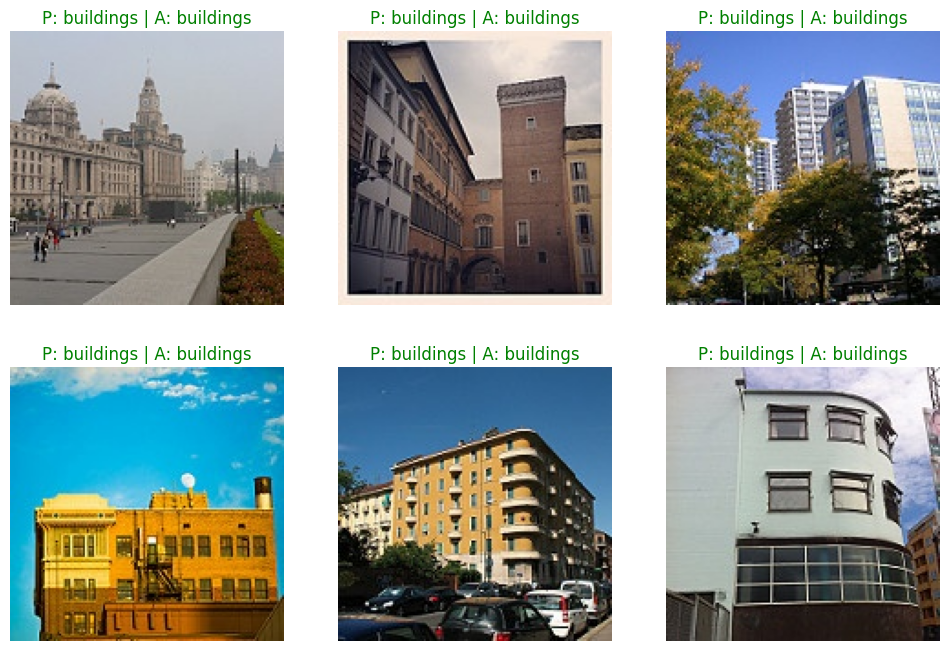

In [68]:
# Final Evaluation: Batch Prediction
images, labels = next(test_data)
preds = deeper_model.predict(images)

plt.figure(figsize=(12, 8))
for i in range(6): # Plotting 6 for speed
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    p_idx, a_idx = np.argmax(preds[i]), np.argmax(labels[i])
    color = 'green' if p_idx == a_idx else 'red'
    plt.title(f"P: {class_names[p_idx]} | A: {class_names[a_idx]}", color=color)
    plt.axis('off')
plt.show()

**Experimentataion and Comparative Analysis:**

**1. Baseline vs Deeper Model Performance:**

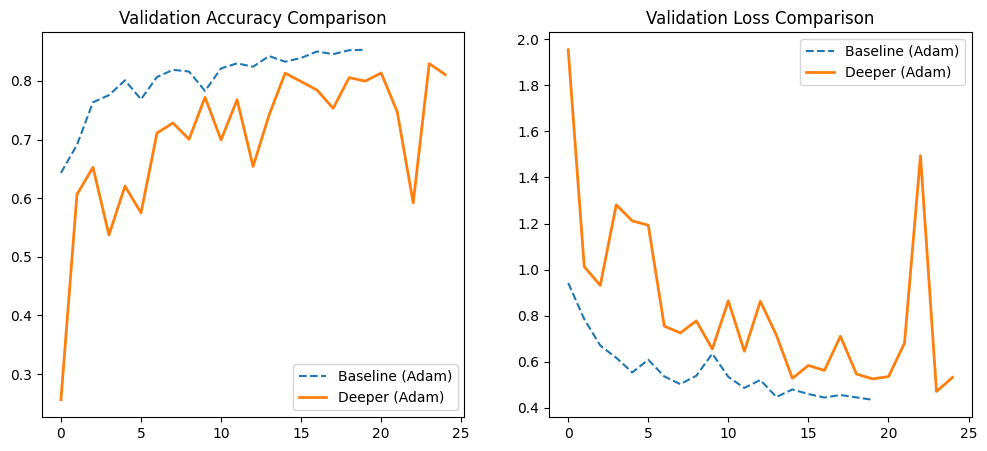

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (Adam)', linestyle='--')
plt.plot(history_deeper.history['val_accuracy'], label='Deeper (Adam)', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline (Adam)', linestyle='--')
plt.plot(history_deeper.history['val_loss'], label='Deeper (Adam)', linewidth=2)
plt.title('Validation Loss Comparison')
plt.legend()
plt.show()

**2. Computational Efficiency:**

In [34]:

deeper_model_sgd = tf.keras.models.clone_model(deeper_model)
deeper_model_sgd.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Optimizer Analysis: Training with SGD ---")
start_sgd = time.time()
history_sgd = deeper_model_sgd.fit(
    train_generator,
    validation_data=val_data,
    epochs=10
)

sgd_duration = time.time() - start_sgd



--- Optimizer Analysis: Training with SGD ---
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 389ms/step - accuracy: 0.5033 - loss: 1.3317 - val_accuracy: 0.2336 - val_loss: 2.6060
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 131s 372ms/step - accuracy: 0.6133 - loss: 1.0065 - val_accuracy: 0.5874 - val_loss: 1.1338
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 140s 366ms/step - accuracy: 0.6609 - loss: 0.8967 - val_accuracy: 0.6213 - val_loss: 0.9964
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 129s 368ms/step - accuracy: 0.7068 - loss: 0.8071 - val_accuracy: 0.6673 - val_loss: 0.9199
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 364ms/step - accuracy: 0.7238 - loss: 0.7521 - val_accuracy: 0.7058 - val_loss: 0.7667
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 362ms/step - accuracy: 0.7476 - loss: 0.6979 - val_accuracy: 0.7382 - val_loss: 0.6946
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 129s 366ms/step - accuracy: 0.7612 - loss: 0.6689 - val_accuracy: 0.7664 - val_loss: 0.6287
Epoch 8/10
351/351 ━━━━━━━━━━━

In [51]:
print(f"Total SGD Training Time: {sgd_duration:.2f} seconds")

Total SGD Training Time: 1323.09 seconds


In [35]:
baseline_epochs = len(history_baseline.history['val_accuracy'])
deeper_epochs = len(history_deeper.history['val_accuracy'])
sgd_epochs = len(history_sgd.history['val_accuracy'])

data = {
    "Model": [
        "Baseline CNN",
        "Deeper CNN (Adam)",
        "Deeper CNN (SGD)"
    ],
    "Total Epochs": [
        baseline_epochs,
        deeper_epochs,
        sgd_epochs
    ],
    "Total Training Time (s)": [
        baseline_duration,
        deeper_duration,
        sgd_duration
    ],
    "Avg Time per Epoch (s)": [
        baseline_duration / baseline_epochs,
        deeper_duration / deeper_epochs,
        sgd_duration / sgd_epochs
    ],
    "Final Val Accuracy": [
        history_baseline.history['val_accuracy'][-1],
        history_deeper.history['val_accuracy'][-1],
        history_sgd.history['val_accuracy'][-1]
    ],
    "Final Val Loss": [
        history_baseline.history['val_loss'][-1],
        history_deeper.history['val_loss'][-1],
        history_sgd.history['val_loss'][-1]
    ]
}

efficiency_df = pd.DataFrame(data)

print("---  Experimentation: Comparative Analysis ---")
display(efficiency_df)

---  Experimentation: Comparative Analysis ---


,Model,Total Epochs,Total Training Time (s),Avg Time per Epoch (s),Final Val Accuracy,Final Val Loss
0,Baseline CNN,20,6169.261658,308.463083,0.853067,0.434551
1,Deeper CNN (Adam),25,3342.741899,133.709676,0.810628,0.531582
2,Deeper CNN (SGD),10,1323.086715,132.308672,0.769258,0.628346


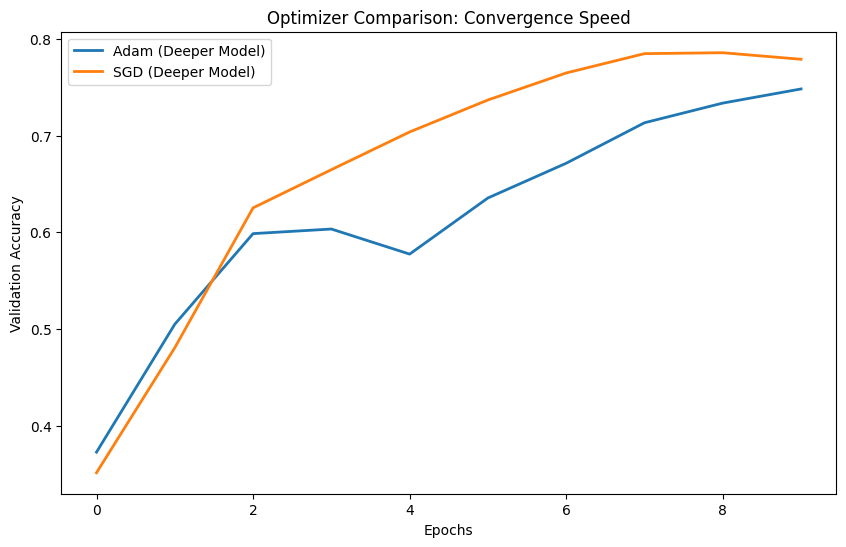

Adam Val Accuracy: 0.8295
SGD Val Accuracy: 0.7981


In [56]:
plt.figure(figsize=(10, 6))
# We plot the first 10 epochs of Adam vs the 10 epochs of SGD
plt.plot(smooth(history_deeper.history['val_accuracy'][:10]), label='Adam (Deeper Model)', linewidth=2)
plt.plot(smooth(history_sgd.history['val_accuracy']), label='SGD (Deeper Model)', linewidth=2)
plt.title('Optimizer Comparison: Convergence Speed')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

# Print the comparison
print(f"Adam Val Accuracy: {max(history_deeper.history['val_accuracy']):.4f}")
print(f"SGD Val Accuracy: {max(history_sgd.history['val_accuracy']):.4f}")

In [37]:

ablation_model = Sequential([
    Input(shape=(150, 150, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'), BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'), MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu', padding='same'), BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'), MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', padding='same'), BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'), MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(len(classes), activation='softmax')
])

ablation_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- Running Ablation Study (No Dropout) ---")
history_ablation = ablation_model.fit(train_generator, validation_data=val_data, epochs=10)

# --- Reporting the Analysis ---
print(f"\n[Ablation Study Results]")
print(f"Deeper Model (with Dropout) Val Acc: {history_deeper.history['val_accuracy'][9]:.4f}")
print(f"Ablation Model (No Dropout) Val Acc: {history_ablation.history['val_accuracy'][-1]:.4f}")


--- Running Ablation Study (No Dropout) ---
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 139s 378ms/step - accuracy: 0.5198 - loss: 2.2249 - val_accuracy: 0.1623 - val_loss: 2.4997
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 362ms/step - accuracy: 0.6502 - loss: 0.9019 - val_accuracy: 0.6298 - val_loss: 0.9018
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 362ms/step - accuracy: 0.7160 - loss: 0.7658 - val_accuracy: 0.5959 - val_loss: 1.1390
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 146s 417ms/step - accuracy: 0.7592 - loss: 0.6577 - val_accuracy: 0.7625 - val_loss: 0.6558
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 365ms/step - accuracy: 0.7825 - loss: 0.6051 - val_accuracy: 0.7183 - val_loss: 0.7364
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 364ms/step - accuracy: 0.8005 - loss: 0.5645 - val_accuracy: 0.8049 - val_loss: 0.5526
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 365ms/step - accuracy: 0.8080 - loss: 0.5444 - val_accuracy: 0.6626 - val_loss: 0.8878
Epoch 8/10
351/351 ━━━━━━━━━━━━

**PartB: Transfer Learning:**

In [38]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

In [39]:

base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_vgg.trainable = False

transfer_model = Sequential([
    base_vgg,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

transfer_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [40]:
transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,638 (64.14 MB)

 Trainable params: 2,098,950 (8.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [41]:

print("Training Transfer Learning Model: Feature Extraction...")
history_transfer = transfer_model.fit(train_generator, validation_data=val_data, epochs=5)

Training Transfer Learning Model: Feature Extraction...
Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 162s 430ms/step - accuracy: 0.7651 - loss: 0.6286 - val_accuracy: 0.8146 - val_loss: 0.4854
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 150s 426ms/step - accuracy: 0.8224 - loss: 0.4751 - val_accuracy: 0.8449 - val_loss: 0.4180
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 135s 385ms/step - accuracy: 0.8305 - loss: 0.4501 - val_accuracy: 0.8477 - val_loss: 0.4015
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 133s 380ms/step - accuracy: 0.8391 - loss: 0.4312 - val_accuracy: 0.8545 - val_loss: 0.3856
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 132s 375ms/step - accuracy: 0.8444 - loss: 0.4063 - val_accuracy: 0.8470 - val_loss: 0.3998


In [42]:
base_vgg.trainable = True
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Transfer Learning: Fine-Tuning...")
history_fine_tune = transfer_model.fit(
    train_generator,
    validation_data=val_data,
    epochs=5
)

Training Transfer Learning: Fine-Tuning...
Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 227s 527ms/step - accuracy: 0.8684 - loss: 0.3529 - val_accuracy: 0.8823 - val_loss: 0.3020
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 155s 442ms/step - accuracy: 0.8996 - loss: 0.2738 - val_accuracy: 0.9041 - val_loss: 0.2797
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 438ms/step - accuracy: 0.9162 - loss: 0.2373 - val_accuracy: 0.8962 - val_loss: 0.2916
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 438ms/step - accuracy: 0.9234 - loss: 0.2113 - val_accuracy: 0.9034 - val_loss: 0.2682
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 156s 444ms/step - accuracy: 0.9308 - loss: 0.1942 - val_accuracy: 0.9151 - val_loss: 0.2510


In [43]:
test_data.reset()
predictions = transfer_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print("--- Transfer Learning Final Performance ---")
print(classification_report(test_data.classes, y_pred, target_names=class_labels))


print(f"Baseline Accuracy: {history_baseline.history['val_accuracy'][-1]:.4f}")
print(f"Deeper Model Accuracy: {history_deeper.history['val_accuracy'][-1]:.4f}")
print(f"Transfer Learning Accuracy: {history_fine_tune.history['val_accuracy'][-1]:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 231ms/step
--- Transfer Learning Final Performance ---
              precision    recall  f1-score   support

   buildings       0.94      0.89      0.92       437
      forest       0.98      0.99      0.98       474
     glacier       0.89      0.86      0.88       553
    mountain       0.89      0.87      0.88       525
         sea       0.94      0.97      0.95       510
      street       0.90      0.95      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000

Baseline Accuracy: 0.8531
Deeper Model Accuracy: 0.8106
Transfer Learning Accuracy: 0.9151


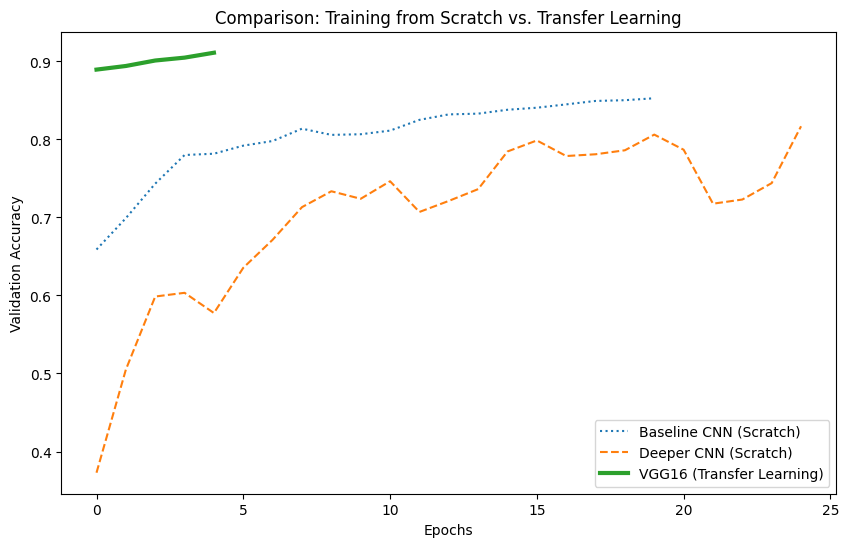

In [44]:

plt.figure(figsize=(10, 6))
plt.plot(smooth(history_baseline.history['val_accuracy']), label='Baseline CNN (Scratch)', linestyle=':')
plt.plot(smooth(history_deeper.history['val_accuracy']), label='Deeper CNN (Scratch)', linestyle='--')
plt.plot(smooth(history_fine_tune.history['val_accuracy']), label='VGG16 (Transfer Learning)', linewidth=3)

plt.title('Comparison: Training from Scratch vs. Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

In [64]:
final_comparison = {
    "Model": ["Baseline", "Deeper (Adam)", "Deeper (SGD)", "Transfer Learning (VGG16)"],
    "Accuracy": [
        max(history_baseline.history['val_accuracy']),
        max(history_deeper.history['val_accuracy']),
        max(history_sgd.history['val_accuracy']),
        max(history_fine_tune.history['val_accuracy'])
    ],
    "Training Time (s)": [
        baseline_duration,
        deeper_duration,
        sgd_duration,
        "-"
    ],
    "Hardware used": "Google Colab T4 GPU"
}
print(pd.DataFrame(final_comparison))

                       Model  Accuracy Training Time (s)        Hardware used
0                   Baseline  0.853067       6169.261658  Google Colab T4 GPU
1              Deeper (Adam)  0.829529       3342.741899  Google Colab T4 GPU
2               Deeper (SGD)  0.798146       1323.086715  Google Colab T4 GPU
3  Transfer Learning (VGG16)  0.915121                 -  Google Colab T4 GPU
